# Онтологии

1\.Cтандарты RDFS и OWL, их синтаксис и возможности, примеры использования.

```turtle
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
```

```turtle
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
```

<p class="task" id="1"></p>


1\. Опишите онтологию предметной области "Университ", используя язык RDFS.

Она должна включать:

    - описание класса `University` с подходящим названием на русском языке;
    - описание класса `City` с подходящим названием на русском языке;
    - описание класса `Person` с подходящим названием на русском языке;
    - описание отношения `name` для описания названия университета;
    - описание отношения `established` для описания даты основания университета;
    - описание отношения `rector` для указания ректора университа;
    - описание отношения `dateOfBirth` для указания даты рождения человека;
    - описание отношения `fullName` для указания ФИО человека.
   
Сериализуйте онтологию в формате turtle и вставьте в виде текстовой ячейки.

- [ ] Проверено на семинаре

In [ ]:
!pip install rdflib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.9/566.9 kB 17.6 MB/s eta 0:00:00


In [ ]:
from rdflib import Graph, Namespace, RDF, RDFS, XSD, Literal, URIRef
g = Graph()
EX = Namespace("http://example.org/university#")
g.bind("ex", EX)
g.bind("rdfs", RDFS)
g.bind("xsd", XSD)

g.add((EX.University, RDF.type, RDFS.Class))
g.add((EX.University, RDFS.label, Literal("Университет", lang="ru")))
g.add((EX.University, RDFS.comment, Literal("Учреждение высшего образования, где проводятся обучение и научные исследования.", lang="ru")))

g.add((EX.City, RDF.type, RDFS.Class))
g.add((EX.City, RDFS.label, Literal("Город", lang="ru")))
g.add((EX.City, RDFS.comment, Literal("Населённый пункт, в котором может располагаться университет.", lang="ru")))

g.add((EX.Person, RDF.type, RDFS.Class))
g.add((EX.Person, RDFS.label, Literal("Человек", lang="ru")))
g.add((EX.Person, RDFS.comment, Literal("Физическое лицо, связанное с университетом (например, ректор).", lang="ru")))


g.add((EX.name, RDF.type, RDF.Property))
g.add((EX.name, RDFS.label, Literal("название", lang="ru")))
g.add((EX.name, RDFS.comment, Literal("Название университета.", lang="ru")))
g.add((EX.name, RDFS.domain, EX.University))
g.add((EX.name, RDFS.range, XSD.string))

g.add((EX.established, RDF.type, RDF.Property))
g.add((EX.established, RDFS.label, Literal("дата основания", lang="ru")))
g.add((EX.established, RDFS.comment, Literal("Дата основания университета.", lang="ru")))
g.add((EX.established, RDFS.domain, EX.University))
g.add((EX.established, RDFS.range, XSD.date))

g.add((EX.rector, RDF.type, RDF.Property))
g.add((EX.rector, RDFS.label, Literal("ректор", lang="ru")))
g.add((EX.rector, RDFS.comment, Literal("Ректор, возглавляющий университет.", lang="ru")))
g.add((EX.rector, RDFS.domain, EX.University))
g.add((EX.rector, RDFS.range, EX.Person))

g.add((EX.dateOfBirth, RDF.type, RDF.Property))
g.add((EX.dateOfBirth, RDFS.label, Literal("дата рождения", lang="ru")))
g.add((EX.dateOfBirth, RDFS.comment, Literal("Дата рождения человека.", lang="ru")))
g.add((EX.dateOfBirth, RDFS.domain, EX.Person))
g.add((EX.dateOfBirth, RDFS.range, XSD.date))

g.add((EX.fullName, RDF.type, RDF.Property))
g.add((EX.fullName, RDFS.label, Literal("ФИО", lang="ru")))
g.add((EX.fullName, RDFS.comment, Literal("Полное имя (ФИО) человека.", lang="ru")))
g.add((EX.fullName, RDFS.domain, EX.Person))
g.add((EX.fullName, RDFS.range, XSD.string))


g.add((EX.locatedIn, RDF.type, RDF.Property))
g.add((EX.locatedIn, RDFS.label, Literal("расположен в", lang="ru")))
g.add((EX.locatedIn, RDFS.comment, Literal("Город, в котором расположен университет.", lang="ru")))
g.add((EX.locatedIn, RDFS.domain, EX.University))
g.add((EX.locatedIn, RDFS.range, EX.City))

print(g.serialize(format="turtle"))


@prefix ex: <http://example.org/university#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

ex:City a rdfs:Class ;
    rdfs:label "Город"@ru ;
    rdfs:comment "Населённый пункт, в котором может располагаться университет."@ru .

ex:Person a rdfs:Class ;
    rdfs:label "Человек"@ru ;
    rdfs:comment "Физическое лицо, связанное с университетом (например, ректор)."@ru .

ex:University a rdfs:Class ;
    rdfs:label "Университет"@ru ;
    rdfs:comment "Учреждение высшего образования, где проводятся обучение и научные исследования."@ru .

ex:dateOfBirth a rdf:Property ;
    rdfs:label "дата рождения"@ru ;
    rdfs:comment "Дата рождения человека."@ru ;
    rdfs:domain ex:Person ;
    rdfs:range xsd:date .

ex:established a rdf:Property ;
    rdfs:label "дата основания"@ru ;
    rdfs:comment "Дата основания университета."@ru ;
    rdfs:domain ex:University ;
    rdfs:ra

<p class="task" id="2"></p>


2\. Напишите SPARQL-запрос, который выводит на экран набор классов (идентификатор и название на русском), используемых в данной предметной области.

- [ ] Проверено на семинаре

In [ ]:
from rdflib import Graph, Namespace, RDF, RDFS, XSD, Literal


g = Graph()

EX = Namespace("http://example.org/university#")
g.bind("ex", EX)
g.bind("rdfs", RDFS)

g.add((EX.University, RDF.type, RDFS.Class))
g.add((EX.University, RDFS.label, Literal("Университет", lang="ru")))
g.add((EX.University, RDFS.comment, Literal("Учреждение высшего образования, где проводятся обучение и научные исследования.", lang="ru")))

g.add((EX.City, RDF.type, RDFS.Class))
g.add((EX.City, RDFS.label, Literal("Город", lang="ru")))
g.add((EX.City, RDFS.comment, Literal("Населённый пункт, в котором может располагаться университет.", lang="ru")))

g.add((EX.Person, RDF.type, RDFS.Class))
g.add((EX.Person, RDFS.label, Literal("Человек", lang="ru")))
g.add((EX.Person, RDFS.comment, Literal("Физическое лицо, связанное с университетом (например, ректор).", lang="ru")))


query = """
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ex:   <http://example.org/university#>

SELECT ?class ?label
WHERE {
    ?class rdf:type rdfs:Class .
    ?class rdfs:label ?label .
    FILTER (lang(?label) = "ru")
}
ORDER BY ?label
"""

for row in g.query(query):
    print(f"Класс: {row['class']}")
    print(f"Название: {row['label']}\n")


Класс: http://example.org/university#City
Название: Город

Класс: http://example.org/university#University
Название: Университет

Класс: http://example.org/university#Person
Название: Человек



<p class="task" id="3"></p>


3\. Напишите SPARQL-запрос, который выводит на экран набор отношений (идентификатор, домен и множество допустимых значений), используемых в данной предметной области.

- [ ] Проверено на семинаре

In [ ]:
EX = Namespace("http://example.org/university#")
g.bind("ex", EX)
g.bind("rdfs", RDFS)
g.bind("xsd", XSD)

g.add((EX.University, RDF.type, RDFS.Class))
g.add((EX.City, RDF.type, RDFS.Class))
g.add((EX.Person, RDF.type, RDFS.Class))

g.add((EX.name, RDF.type, RDF.Property))
g.add((EX.name, RDFS.domain, EX.University))
g.add((EX.name, RDFS.range, XSD.string))

g.add((EX.established, RDF.type, RDF.Property))
g.add((EX.established, RDFS.domain, EX.University))
g.add((EX.established, RDFS.range, XSD.date))

g.add((EX.rector, RDF.type, RDF.Property))
g.add((EX.rector, RDFS.domain, EX.University))
g.add((EX.rector, RDFS.range, EX.Person))

g.add((EX.dateOfBirth, RDF.type, RDF.Property))
g.add((EX.dateOfBirth, RDFS.domain, EX.Person))
g.add((EX.dateOfBirth, RDFS.range, XSD.date))

g.add((EX.fullName, RDF.type, RDF.Property))
g.add((EX.fullName, RDFS.domain, EX.Person))
g.add((EX.fullName, RDFS.range, XSD.string))

g.add((EX.locatedIn, RDF.type, RDF.Property))
g.add((EX.locatedIn, RDFS.domain, EX.University))
g.add((EX.locatedIn, RDFS.range, EX.City))

query = """
PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ex:   <http://example.org/university#>

SELECT ?property ?domain ?range
WHERE {
    ?property rdf:type rdf:Property .
    OPTIONAL { ?property rdfs:domain ?domain . }
    OPTIONAL { ?property rdfs:range ?range . }
}
ORDER BY ?property
"""

print("СВОЙСТВА ОНТОЛОГИИ 'УНИВЕРСИТЕТ'\n" + "-"*60)
for row in g.query(query):
    print(f"Отношение: {row['property']}")
    print(f"  Домен: {row['domain']}")
    print(f"  Допустимые значения (range): {row['range']}\n")

СВОЙСТВА ОНТОЛОГИИ 'УНИВЕРСИТЕТ'
------------------------------------------------------------
Отношение: http://example.org/university#dateOfBirth
  Домен: http://example.org/university#Person
  Допустимые значения (range): http://www.w3.org/2001/XMLSchema#date

Отношение: http://example.org/university#established
  Домен: http://example.org/university#University
  Допустимые значения (range): http://www.w3.org/2001/XMLSchema#date

Отношение: http://example.org/university#fullName
  Домен: http://example.org/university#Person
  Допустимые значения (range): http://www.w3.org/2001/XMLSchema#string

Отношение: http://example.org/university#locatedIn
  Домен: http://example.org/university#University
  Допустимые значения (range): http://example.org/university#City

Отношение: http://example.org/university#name
  Домен: http://example.org/university#University
  Допустимые значения (range): http://www.w3.org/2001/XMLSchema#string

Отношение: http://example.org/university#rector
  Домен: htt

<p class="task" id="4"></p>


4\. Опишите онтологию той же предметной области, используя язык OWL2.

Дополнительно укажите, что отношения "университет располагается в городе" и "дата рождения человека" являются функциональным. Для отношения "дата рождения человека" укажите ограничение на минимальное и максимальное значение (01.01.1900 и 01.01.2000 соответственно).

Для создания онтологии используйте инструмент Protégé (предпочтительно десктопную версию). После завершения формирования онтологии сделайте скриншоты иерархии классов, object properties и data properties и вставьте в ноутбук.

Сериализуйте онтологию в формате turtle и вставьте в виде текстовой ячейки.

- [ ] Проверено на семинаре

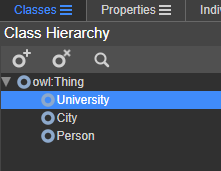

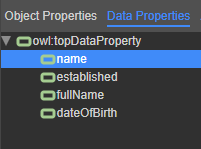

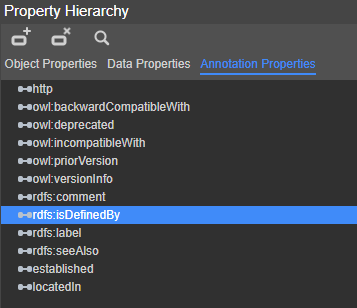

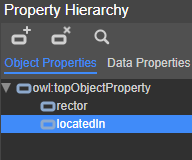

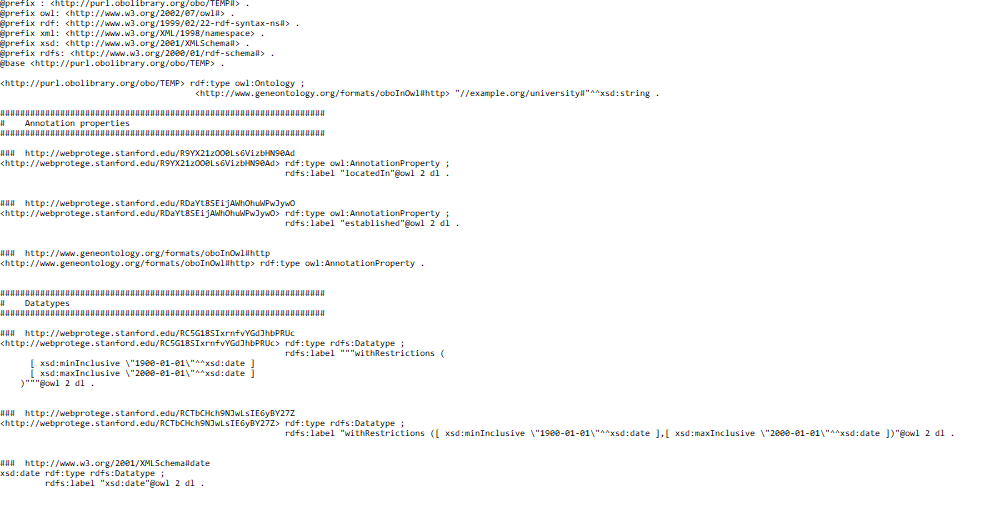

это вариант без protege на всякий случай

In [ ]:
from rdflib import Graph, Namespace, RDF, RDFS, OWL, XSD, Literal, BNode

g = Graph()

EX = Namespace("http://example.org/university#")
g.bind("ex", EX)
g.bind("owl", OWL)
g.bind("rdfs", RDFS)
g.bind("xsd", XSD)

g.add((EX.University, RDF.type, OWL.Class))
g.add((EX.University, RDFS.label, Literal("Университет", lang="ru")))

g.add((EX.City, RDF.type, OWL.Class))
g.add((EX.City, RDFS.label, Literal("Город", lang="ru")))

g.add((EX.Person, RDF.type, OWL.Class))
g.add((EX.Person, RDFS.label, Literal("Человек", lang="ru")))


g.add((EX.locatedIn, RDF.type, OWL.ObjectProperty))
g.add((EX.locatedIn, RDFS.label, Literal("расположен в", lang="ru")))
g.add((EX.locatedIn, RDFS.domain, EX.University))
g.add((EX.locatedIn, RDFS.range, EX.City))

g.add((EX.locatedIn, RDF.type, OWL.FunctionalProperty))

g.add((EX.name, RDF.type, OWL.DatatypeProperty))
g.add((EX.name, RDFS.domain, EX.University))
g.add((EX.name, RDFS.range, XSD.string))
g.add((EX.name, RDFS.label, Literal("название", lang="ru")))

g.add((EX.established, RDF.type, OWL.DatatypeProperty))
g.add((EX.established, RDFS.domain, EX.University))
g.add((EX.established, RDFS.range, XSD.date))
g.add((EX.established, RDFS.label, Literal("дата основания", lang="ru")))

g.add((EX.rector, RDF.type, OWL.ObjectProperty))
g.add((EX.rector, RDFS.domain, EX.University))
g.add((EX.rector, RDFS.range, EX.Person))
g.add((EX.rector, RDFS.label, Literal("ректор", lang="ru")))

g.add((EX.fullName, RDF.type, OWL.DatatypeProperty))
g.add((EX.fullName, RDFS.domain, EX.Person))
g.add((EX.fullName, RDFS.range, XSD.string))
g.add((EX.fullName, RDFS.label, Literal("ФИО", lang="ru")))

g.add((EX.dateOfBirth, RDF.type, OWL.DatatypeProperty))
g.add((EX.dateOfBirth, RDFS.domain, EX.Person))
g.add((EX.dateOfBirth, RDFS.range, XSD.date))
g.add((EX.dateOfBirth, RDFS.label, Literal("дата рождения", lang="ru")))

g.add((EX.dateOfBirth, RDF.type, OWL.FunctionalProperty))

restriction = BNode()
g.add((restriction, RDF.type, RDFS.Datatype))
g.add((restriction, OWL.onDatatype, XSD.date))
g.add((restriction, OWL.withRestrictions, BNode()))

restriction_list = BNode()
g.add((restriction, OWL.withRestrictions, restriction_list))

min_restr = BNode()
max_restr = BNode()

g.add((restriction_list, RDF.first, min_restr))
g.add((min_restr, XSD.minInclusive, Literal("1900-01-01", datatype=XSD.date)))

next_list = BNode()
g.add((restriction_list, RDF.rest, next_list))
g.add((next_list, RDF.first, max_restr))
g.add((max_restr, XSD.maxInclusive, Literal("2000-01-01", datatype=XSD.date)))
g.add((next_list, RDF.rest, RDF.nil))

g.add((EX.dateOfBirth, RDFS.range, restriction))

print(g.serialize(format="turtle"))


@prefix ex: <http://example.org/university#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

ex:dateOfBirth a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "дата рождения"@ru ;
    rdfs:domain ex:Person ;
    rdfs:range [ a rdfs:Datatype ;
            owl:onDatatype xsd:date ;
            owl:withRestrictions [ ],
                ( [ xsd:minInclusive "1900-01-01"^^xsd:date ] [ xsd:maxInclusive "2000-01-01"^^xsd:date ] ) ],
        xsd:date .

ex:established a owl:DatatypeProperty ;
    rdfs:label "дата основания"@ru ;
    rdfs:domain ex:University ;
    rdfs:range xsd:date .

ex:fullName a owl:DatatypeProperty ;
    rdfs:label "ФИО"@ru ;
    rdfs:domain ex:Person ;
    rdfs:range xsd:string .

ex:locatedIn a owl:FunctionalProperty,
        owl:ObjectProperty ;
    rdfs:label "расположен в"@ru ;

<p class="task" id="5"></p>


5\. В файлах `data1.ttl` и `data2.ttl` находится информация о различных языках программирования. Эти данные получены из различных источников, имеющих различные схемы для хранения данных. Разработайте онтологию в формате OWL2 для объединения этих двух источников данных. Для этого опишите класс "Язык программирования" и набор атрибутов. Данную онтологию сохраните в отдельный файл `ontology.owl`.

Чтобы связать онтологию и имеющиеся данные, создайте файл `extra.ttl`, в котором укажите, какие свойства являются эквивалентными. Там же укажите, какие субъекты (конкретные языки программирования) являются эквивалентными.

Вставьте содержимое двух созданных файлов в виде текстовых ячеек.

- [ ] Проверено на семинаре

In [ ]:
from rdflib import Graph, Namespace, RDF, RDFS, OWL, Literal, XSD

ONTO = Namespace("http://unifiedschema.org/schema#")
RES1 = Namespace("http://resource1.org/schema#")
RES2 = Namespace("http://resource2.org/schema#")

g_onto = Graph()
g_onto.bind("onto", ONTO)
g_onto.bind("owl", OWL)
g_onto.bind("rdfs", RDFS)
g_onto.bind("xsd", XSD)

g_onto.add((ONTO.ProgrammingLanguage, RDF.type, OWL.Class))
g_onto.add((ONTO.ProgrammingLanguage, RDFS.label, Literal("Язык программирования", lang="ru")))

props = {
    "name": XSD.string,
    "creator": XSD.string,
    "releaseYear": XSD.gYear,
    "latestVersion": XSD.string,
    "paradigm": XSD.string,
    "isPopular": XSD.boolean
}

for p, dtype in props.items():
    g_onto.add((ONTO[p], RDF.type, OWL.DatatypeProperty))
    g_onto.add((ONTO[p], RDFS.domain, ONTO.ProgrammingLanguage))
    g_onto.add((ONTO[p], RDFS.range, dtype))
    g_onto.add((ONTO[p], RDFS.label, Literal(p, lang="ru")))

g_onto.serialize("ontology.owl", format="turtle")

g_extra = Graph()
g_extra.bind("onto", ONTO)
g_extra.bind("res1", RES1)
g_extra.bind("res2", RES2)
g_extra.bind("owl", OWL)

equiv_props = {
    RES1.name: ONTO.name,
    RES1.creator: ONTO.creator,
    RES1.releaseYear: ONTO.releaseYear,
    RES1.latestVersion: ONTO.latestVersion,
    RES2.langName: ONTO.name,
    RES2.inventor: ONTO.creator,
    RES2.yearReleased: ONTO.releaseYear,
    RES2.currentVersion: ONTO.latestVersion,
    RES2.paradigmUsed: ONTO.paradigm,
    RES2.isPopular: ONTO.isPopular
}

for k, v in equiv_props.items():
    g_extra.add((k, OWL.equivalentProperty, v))

equiv_subjects = {
    RES1.Python: RES2.PythonLang,
    RES1.JavaScript: RES2.JS,
    RES1.Ruby: RES2.RubyLang
}

for k, v in equiv_subjects.items():
    g_extra.add((k, OWL.sameAs, v))

g_extra.serialize("extra.ttl", format="turtle")


<Graph identifier=Na4adc2705a4747b1aad7e4d9553fd4be (<class 'rdflib.graph.Graph'>)>

<p class="task" id="6"></p>


6\. При помощи `rdflib` создайте граф на основе четырех имеющихся файлов. Напишите запрос на SPARQL, который для каждого отношения из онтологии позволит узнать, сколько и каких существует эквивалентных свойств в файлах с данными.

- [ ] Проверено на семинаре

In [ ]:
from rdflib import Graph, Namespace, OWL, RDFS

g = Graph()
g.parse("ontology.owl", format="turtle")
g.parse("extra.ttl", format="turtle")
g.parse("data1.ttl", format="turtle")
g.parse("data2.ttl", format="turtle")


ONTO = Namespace("http://unifiedschema.org/schema#")
RES1 = Namespace("http://resource1.org/schema#")
RES2 = Namespace("http://resource2.org/schema#")

query = """
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?ontologyProp (COUNT(?equivProp) AS ?equivCount) (GROUP_CONCAT(?equivProp; separator=", ") AS ?equivProps)
WHERE {
    ?ontologyProp a owl:DatatypeProperty .
    OPTIONAL {
        ?equivProp owl:equivalentProperty ?ontologyProp .
    }
}
GROUP BY ?ontologyProp
ORDER BY ?ontologyProp
"""
print("Эквивалентные свойства для свойств из онтологии:\n")
for row in g.query(query):
    print(f"Свойство онтологии: {row.ontologyProp}")
    print(f"Количество эквивалентных свойств: {row.equivCount}")
    print(f"Список эквивалентных свойств: {row.equivProps}\n")


Эквивалентные свойства для свойств из онтологии:

Свойство онтологии: http://unifiedschema.org/schema#creator
Количество эквивалентных свойств: 2
Список эквивалентных свойств: http://resource1.org/schema#creator, http://resource2.org/schema#inventor

Свойство онтологии: http://unifiedschema.org/schema#isPopular
Количество эквивалентных свойств: 1
Список эквивалентных свойств: http://resource2.org/schema#isPopular

Свойство онтологии: http://unifiedschema.org/schema#latestVersion
Количество эквивалентных свойств: 2
Список эквивалентных свойств: http://resource1.org/schema#latestVersion, http://resource2.org/schema#currentVersion

Свойство онтологии: http://unifiedschema.org/schema#name
Количество эквивалентных свойств: 2
Список эквивалентных свойств: http://resource1.org/schema#name, http://resource2.org/schema#langName

Свойство онтологии: http://unifiedschema.org/schema#paradigm
Количество эквивалентных свойств: 1
Список эквивалентных свойств: http://resource2.org/schema#paradigmUsed


<p class="task" id="7"></p>


7\. Напишите запрос, который выводит всю информацию о языках программирования из файла `data1.ttl`, расширенную за счет недостающей информации из `data2.ttl`. Для связки двух файлов используйте новые тройки из файла `extra.ttl`.

- [ ] Проверено на семинаре

In [ ]:
from rdflib import Graph, OWL

g = Graph()
g.parse("data1.ttl", format="turtle")
g.parse("data2.ttl", format="turtle")
g.parse("extra.ttl", format="turtle")

query = """
PREFIX owl: <http://www.w3.org/2002/07/owl#>

SELECT ?lang ?prop ?value
WHERE {
  {
    ?lang ?prop ?value .
    FILTER(STRSTARTS(STR(?lang), "http://resource1.org/schema#"))
  }
  UNION
  {
    ?lang owl:sameAs|^owl:sameAs ?lang2 .
    ?lang2 ?prop ?value .
    FILTER(STRSTARTS(STR(?lang2), "http://resource2.org/schema#")) .
  }
}
ORDER BY ?lang ?prop
"""

results = g.query(query)

for row in results:
    print(f"{row.lang} | {row.prop} | {row.value}")



Язык программирования: http://resource1.org/schema#Java
  http://unifiedschema.org/schema#name = Java
  http://unifiedschema.org/schema#creator = James Gosling
  http://unifiedschema.org/schema#latestVersion = 17
  http://unifiedschema.org/schema#releaseYear = 1995
  http://www.w3.org/1999/02/22-rdf-syntax-ns#type = http://resource1.org/schema#programmingLanguage

Язык программирования: http://resource1.org/schema#Python
  http://unifiedschema.org/schema#name = Python
  http://unifiedschema.org/schema#creator = Guido van Rossum
  http://unifiedschema.org/schema#releaseYear = 1991
  http://unifiedschema.org/schema#latestVersion = 3.9.5
  http://www.w3.org/1999/02/22-rdf-syntax-ns#type = http://resource2.org/schema#language
  http://unifiedschema.org/schema#paradigm = Object-Oriented, Procedural
  http://unifiedschema.org/schema#isPopular = true

Язык программирования: http://resource1.org/schema#Ruby
  http://unifiedschema.org/schema#paradigm = Object-Oriented, Functional
  http://unif

<p class="task" id="8"></p>


8\. Напишите запрос, который возвращает создателей всех языков программирования, используя для поиска только отношение из онтологии (в запросе явно можно указать только его, нельзя указать отношения с префиксами res1, res2).

- [ ] Проверено на семинаре

In [ ]:
from rdflib import Graph, Namespace, OWL

g = Graph()
g.parse("ontology.owl", format="turtle")
g.parse("extra.ttl", format="turtle")
g.parse("data1.ttl", format="turtle")
g.parse("data2.ttl", format="turtle")

ONTO = Namespace("http://unifiedschema.org/schema#")
OWL_NS = OWL

query = """
PREFIX onto: <http://unifiedschema.org/schema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>

SELECT DISTINCT ?creator
WHERE {
    {
        ?lang onto:creator ?creator .
    }
    UNION
    {
        # Ищем эквивалентные свойства через owl:equivalentProperty
        ?prop owl:equivalentProperty onto:creator .
        ?lang ?prop ?creator .
    }
}
ORDER BY ?creator
"""

results = g.query(query)

print("Список создателей языков программирования:\n")
for row in results:
    print(row.creator)


Список создателей языков программирования:

Brendan Eich
Guido van Rossum
James Gosling
JetBrains
Microsoft
Yukihiro Matsumoto
